# OpenCV

In [1]:
# SIFT (Scale-Invariant Feature Transform) patent expired in March 2020.
# It is now included in the main opencv-python and opencv-contrib-python packages.
# Install the latest version to support modern Python (e.g., 3.13).
!pip install opencv-contrib-python numpy scipy scikit-learn joblib matplotlib seaborn pandas


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Extract Data

In [2]:
import os
import zipfile as zf
import requests

def download_dataset():
    url = "https://huggingface.co/datasets/garythung/trashnet/resolve/main/dataset-resized.zip"
    filename = "dataset-resized.zip"
    
    if not os.path.exists(filename) and not os.path.exists("dataset-resized"):
        print("Downloading TrashNet dataset from Hugging Face...")
        r = requests.get(url, stream=True)
        with open(filename, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1024):
                if chunk: f.write(chunk)
        print("Download complete.")
    
    if os.path.exists(filename):
        with zf.ZipFile(filename, 'r') as files:
            files.extractall()
        print("Dataset extracted successfully.")
    else:
        print("Dataset folder already exists or was extracted.")

download_dataset()

Dataset extracted successfully.


# File Organizing
Splits indices for a folder into train and test indices with random sampling

In [3]:
import random
import shutil
import os

## Input: folder path
## Output: train and test indices
def split_indices(folder, seed1, seed2):
    n = len(os.listdir(folder))
    full_set = list(range(1, n + 1))

    ## Train indices
    random.seed(seed1)
    train = random.sample(list(range(1, n + 1)), int(.85 * n))

    ## Separate remaining into test
    test = list(set(full_set) - set(train))

    return(train, test)

## Gets file names for a particular type of trash, given indices
## Input: waste category and indices
## Output: file names
def get_names(waste_type, indices):
    file_names = [waste_type + str(i) + ".jpg" for i in indices]
    return(file_names)

## Moves group of source files to another folder
## Input: list of source files and destination folder
## No output
def move_files(source_files, destination_folder):
    for file in source_files:
        shutil.move(file, destination_folder)

In [4]:
## Paths will be train/cardboard, train/glass, etc...
subsets = ['train', 'test']
waste_types = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

## Create destination folders for data subset and waste type
for subset in subsets:
    for waste_type in waste_types:
        folder = os.path.join('dataset', subset, waste_type)
        if not os.path.exists(folder):
            os.makedirs(folder)

## Move files to destination folders for each waste type
for waste_type in waste_types:
    source_folder = os.path.join('dataset-resized', waste_type)
    train_ind, test_ind = split_indices(source_folder, 1, 1)

    ## Move source files to train
    train_names = get_names(waste_type, train_ind)
    train_source_files = [os.path.join(source_folder, name) for name in train_names]
    train_dest = "dataset/train/" + waste_type
    move_files(train_source_files, train_dest)

    ## Move source files to test
    test_names = get_names(waste_type, test_ind)
    test_source_files = [os.path.join(source_folder, name) for name in test_names]
    test_dest = "dataset/test/" + waste_type
    move_files(test_source_files, test_dest)

#Training

In [5]:
# Get the training classes names and store them in a list
# Use folder names for class names
train_path = './dataset/train'
training_names = os.listdir(train_path)

# Get path to all images and save them in a list image_paths and the corresponding label in image_paths
image_paths = []
image_classes = []
class_id = 0

# To list all file names in a directory
def imglist(path):
    return [os.path.join(path, f) for f in os.listdir(path)]

# Fill the placeholder empty lists with image path, classes, and add class ID number
for training_name in training_names:
    dir = os.path.join(train_path, training_name)
    class_path = imglist(dir)
    image_paths += class_path
    image_classes += [class_id] * len(class_path)
    class_id += 1

Feature Extraction using Scale Invariant Feature Transform (SIFT) Algorithm

In [6]:
import numpy as np
import cv2

# Create feature extraction and keypoint detector objects using SIFT
des_list = []
sift = cv2.SIFT_create()

for image_path in image_paths:
    im = cv2.imread(image_path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    kpts, des = sift.detectAndCompute(im, None)
    if len(kpts) < 1:
        no_kpts = np.zeros((1, sift.descriptorSize()), np.float32)
        des_list.append((image_path, no_kpts))
    else:
        des_list.append((image_path, des))

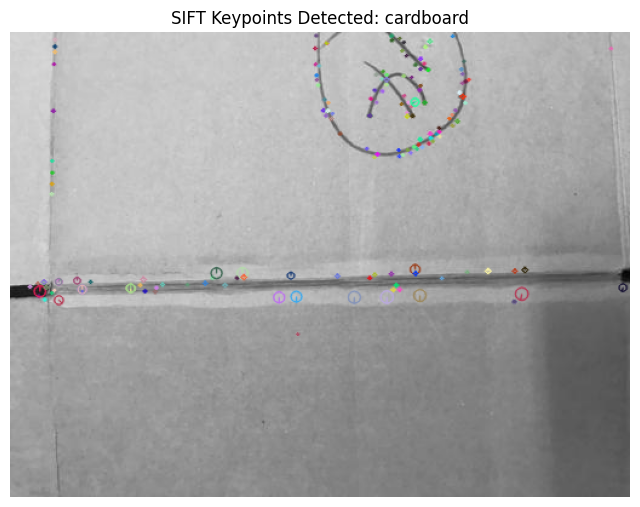

In [7]:
import matplotlib.pyplot as plt

# Visualization: Drawing SIFT Keypoints on a sample image
if 'image_paths' in locals() and 'sift' in locals():
    sample_img_path = image_paths[0]
    sample_img = cv2.imread(sample_img_path)
    sample_gray = cv2.cvtColor(sample_img, cv2.COLOR_BGR2GRAY)
    kp, des = sift.detectAndCompute(sample_gray, None)

    img_kp = cv2.drawKeypoints(sample_gray, kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    plt.figure(figsize=(8,8))
    plt.title(f"SIFT Keypoints Detected: {training_names[image_classes[0]]}")
    plt.imshow(img_kp)
    plt.axis('off')
    plt.show()
else:
    print('Please run the preceding Training and Feature Extraction cells first.')

In [8]:
# Stack all the descriptors vertically in a numpy array
descriptors = des_list[0][1]
for image_path, descriptor in des_list[1:]:
    descriptors = np.vstack((descriptors, descriptor))

# kmeans works only on float, so need to convert integers to float
descriptors_float = descriptors.astype(float)

k-means Clustering

In [9]:
from scipy.cluster.vq import kmeans, vq

# Perform k-means clustering and vector quantization
k = 250
voc, variance = kmeans(descriptors_float, k, 1)

In [10]:
# Calculate the histogram of features and represent them as vector vq

im_features = np.zeros((len(image_paths), k), "float32")
for i in range(len(image_paths)):
    words, distance = vq(des_list[i][1], voc)
    for w in words:
        im_features[i][w] += 1

Training the Support Vector Machine (SVM) Algorithm

In [11]:
from sklearn import svm

# Train an algorithm to discriminate vectors corresponding to positive and negative training images
clf = svm.SVC(decision_function_shape = 'ovr', kernel = 'rbf', C = 10, gamma = 1 / (250 * im_features.var()))
clf.fit(im_features, np.array(image_classes))

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",np.float32(0.0002480253)
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Evaluation

In [12]:
# Report true class names so they can be compared with predicted classes
true_class = [training_names[i] for i in image_classes]

# Perform the predictions and report predicted class names.
predictions = [training_names[i] for i in clf.predict(im_features)]

# Print the true class and Predictions
print ("true_class = " + str(true_class))
print ("prediction = " + str(predictions))

true_class = ['cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard'

In [13]:
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(true_class, predictions, digits = 3))

              precision    recall  f1-score   support

   cardboard      0.904     0.851     0.877       342
       glass      0.727     0.946     0.822       425
       metal      0.981     0.885     0.931       348
       paper      0.951     0.927     0.939       504
     plastic      0.899     0.829     0.863       409
       trash      0.977     0.733     0.837       116

    accuracy                          0.882      2144
   macro avg      0.906     0.862     0.878      2144
weighted avg      0.895     0.882     0.884      2144



In [14]:
import joblib

# Save the SVM
# Joblib dumps Python object into one file

joblib.dump((clf, training_names, k, voc), "trashnet.pkl", compress = 3)

['trashnet.pkl']

#Testing

In [15]:
# Load the classifier, class names, scaler, number of clusters and vocabulary from stored pickle file (generated during training)
clf, classes_names, k, voc = joblib.load("trashnet.pkl")

# Get the path of the testing image(s) and store them in a list
test_path = './dataset/test'
testing_names = os.listdir(test_path)

# Get path to all images and save them in a list image_paths and the corresponding label in image_paths
image_paths = []
image_classes = []
class_id = 0

In [16]:
# To list all file names in a directory
def imglist(path):
    return [os.path.join(path, f) for f in os.listdir(path)]

# Fill the placeholder empty lists with image path, classes, and add class ID number
for testing_name in testing_names:
    dir = os.path.join(test_path, testing_name)
    class_path = imglist(dir)
    image_paths += class_path
    image_classes += [class_id] * len(class_path)
    class_id += 1

Feature Extraction using Scale Invariant Feature Transform (SIFT) Algorithm

In [17]:
# Create feature extraction and keypoint detector objects using SIFT
# Create list where all the descriptors will be stored
des_list = []
sift = cv2.SIFT_create()

for image_path in image_paths:
    im = cv2.imread(image_path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    kpts, des = sift.detectAndCompute(im, None)
    if len(kpts) < 1:
        no_kpts = np.zeros((1, sift.descriptorSize()), np.float32)
        des_list.append((image_path, no_kpts))
    else:
        des_list.append((image_path, des))

In [18]:
# Stack all the descriptors vertically in a numpy array
descriptors = des_list[0][1]
for image_path, descriptor in des_list[0:]:
    descriptors = np.vstack((descriptors, descriptor))

In [19]:
# Calculate the histogram of features
test_features = np.zeros((len(image_paths), k), "float32")
for i in range(len(image_paths)):
    words, distance = vq(des_list[i][1], voc)
    for w in words:
        test_features[i][w] += 1

Evaluation

In [20]:
# Report true class names so they can be compared with predicted classes
true_class = [classes_names[i] for i in image_classes]

# Perform the predictions and report predicted class names.
predictions = [classes_names[i] for i in clf.predict(test_features)]

# Print the true class and Predictions
print ("true_class = " + str(true_class))
print ("prediction = " + str(predictions))

true_class = ['cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'cardboard', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'glass', 'gla

In [21]:
print(classification_report(true_class, predictions, digits = 3))

              precision    recall  f1-score   support

   cardboard      0.667     0.689     0.677        61
       glass      0.448     0.618     0.519        76
       metal      0.700     0.452     0.549        62
       paper      0.766     0.800     0.783        90
     plastic      0.640     0.658     0.649        73
       trash      0.500     0.143     0.222        21

    accuracy                          0.627       383
   macro avg      0.620     0.560     0.567       383
weighted avg      0.638     0.627     0.620       383



#Data Visualization

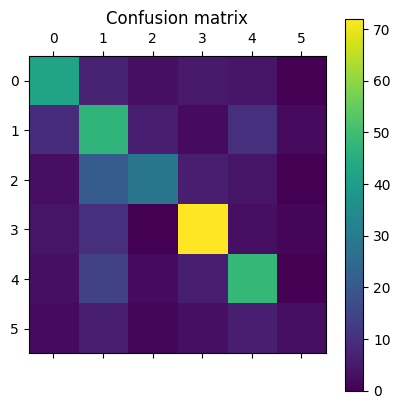

In [22]:
import pylab as pl

# To make it easy to understand the accuracy, print the confusion matrix
def showconfusionmatrix(cm):
    pl.matshow(cm)
    pl.title('Confusion matrix')
    pl.colorbar()
    pl.show()

cm = confusion_matrix(true_class, predictions)
showconfusionmatrix(cm)

<Axes: >

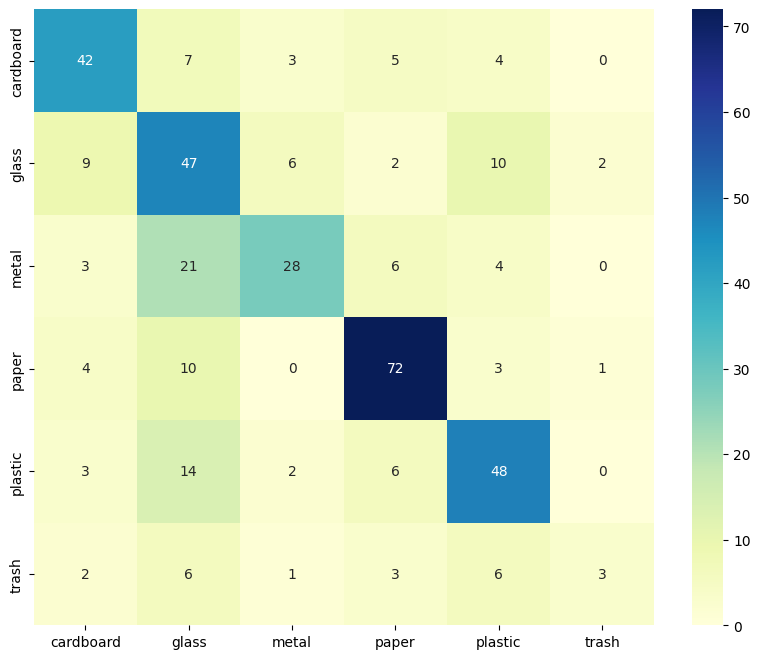

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_cm = pd.DataFrame(cm, waste_types, waste_types)

plt.figure(figsize = (10, 8))
sns.heatmap(df_cm, annot = True, fmt = "d", cmap = "YlGnBu")

# Error Analysis
Visualizing cases where the model failed to identify the correct category.

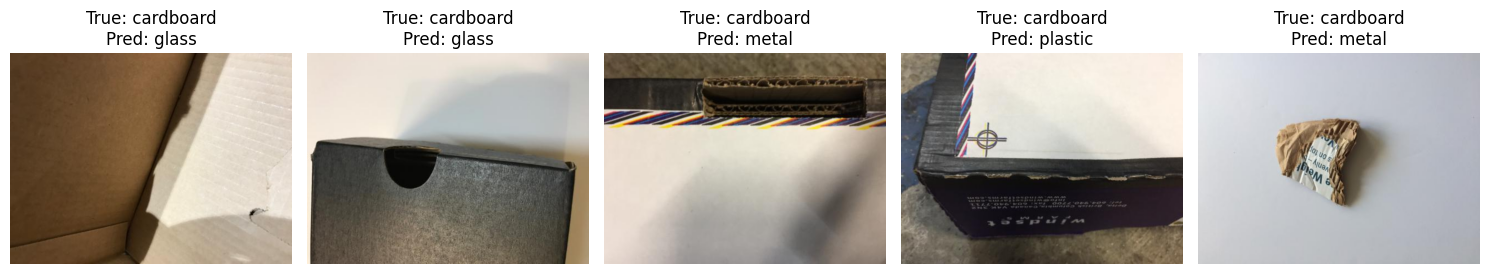

In [24]:
# Find indices of misclassified images
misclassified = [i for i in range(len(true_class)) if true_class[i] != predictions[i]]

plt.figure(figsize=(15, 10))
for i, idx in enumerate(misclassified[:5]): # Show first 5 mistakes
    img = cv2.imread(image_paths[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_class[idx]}\nPred: {predictions[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()